# RQ6 Model families and temporal drift on IEEE-CIS
Two additions to the thesis experiments, using the same data, the same feature set and the same chronological protocol as `RQ2_IEEE_CIS_Explainability.ipynb`.

* **Part A** compares XGBoost with LightGBM and CatBoost (class weighting, 3 seeds).
* **Part B** measures temporal drift: a model trained on the first 90 days is scored on consecutive 30-day blocks and compared with a model that is retrained before each block. Feature drift is measured with the Population Stability Index (PSI).

In [2]:
 !pip install scikit-learn xgboost lightgbm catboost matplotlib seaborn -q
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, time, warnings
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, roc_auc_score)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')
BASE = Path('/content/drive/MyDrive/Bicocca/Thesis code')
DATA_PATH = BASE / 'data' / 'raw' / 'ieee_cis' / 'train_transaction.csv'
OUTDIR = BASE / 'results' / 'ieee_cis_rq6'
FIGDIR = OUTDIR / 'figures'
for p in [OUTDIR, FIGDIR]: p.mkdir(parents=True, exist_ok=True)
SEEDS = [0, 1, 2]
MAX_MISSING_FRAC = 0.50
DAY = 86400

Mounted at /content/drive


## 1. Data and features (identical to RQ2)

In [4]:
df = pd.read_csv(DATA_PATH)
print(df.shape, f"fraud rate {df['isFraud'].mean()*100:.3f}%")
missing_frac = df.isna().mean().sort_values(ascending=False)
keep_cols = missing_frac[missing_frac <= MAX_MISSING_FRAC].index.tolist()
df_reduced = df[keep_cols].copy()
named_cols = ["TransactionID","isFraud","TransactionDT","TransactionAmt","ProductCD",
              "card1","card2","card3","card4","card5","card6","addr1","addr2","dist1","dist2",
              "P_emaildomain","R_emaildomain"] + [c for c in df_reduced.columns if c.startswith("M")]
named_cols = [c for c in named_cols if c in df_reduced.columns]
extra_numeric = [c for c in df_reduced.columns if c.startswith(("C","D","V"))][:15]
final_cols = list(dict.fromkeys(named_cols + extra_numeric))
df_model = df_reduced[final_cols].sort_values("TransactionDT").reset_index(drop=True)
del df

categorical_cols = df_model.select_dtypes(include="object").columns.tolist()
numeric_cols = [c for c in df_model.columns if c not in categorical_cols + ["TransactionID","isFraud"]]
for col in categorical_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].fillna("missing").astype(str))
feature_cols = categorical_cols + numeric_cols
df_model["day"] = (df_model["TransactionDT"] - df_model["TransactionDT"].min()) // DAY
print("features:", len(feature_cols), "| days covered:", int(df_model['day'].max()) + 1)

(590540, 394) fraud rate 3.499%
features: 32 | days covered: 182


In [5]:
def fill_numeric(train_df, other_dfs):
    med = train_df[numeric_cols].median()
    out = [train_df.fillna(med)] + [d.fillna(med) for d in other_dfs]
    return out

def metrics(y, score, thr=0.5):
    pred = (score >= thr).astype(int)
    return {"precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
            "pr_auc": average_precision_score(y, score),
            "roc_auc": roc_auc_score(y, score),
            "prevalence": y.mean(), "alerts": int(pred.sum())}

def make_model(name, y_tr, seed):
    pos = y_tr.mean(); spw = (1 - pos) / pos
    if name == "XGBoost":
        return xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                 scale_pos_weight=spw, eval_metric="aucpr",
                                 random_state=seed, n_jobs=-1)
    if name == "LightGBM":
        return lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                  scale_pos_weight=spw, random_state=seed,
                                  n_jobs=-1, verbose=-1)
    if name == "CatBoost":
        return CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1,
                                  scale_pos_weight=spw, random_seed=seed, verbose=0,
                                  thread_count=-1)
    raise ValueError(name)

## Part A. XGBoost vs LightGBM vs CatBoost (70/10/20 chronological split, as in RQ2)

In [6]:
n = len(df_model); n_test = int(n*0.2); n_val = int(n*0.1); n_train = n - n_test - n_val
tr_raw, te_raw = df_model.iloc[:n_train], df_model.iloc[n_train+n_val:]
tr, te = fill_numeric(tr_raw, [te_raw])
Xtr, ytr, Xte, yte = tr[feature_cols], tr["isFraud"], te[feature_cols], te["isFraud"]
print(f"train {len(tr):,}  test {len(te):,}  test fraud rate {yte.mean()*100:.3f}%")

rowsA = []
for name in ["XGBoost", "LightGBM", "CatBoost"]:
    for seed in SEEDS:
        t0 = time.time(); m = make_model(name, ytr, seed); m.fit(Xtr, ytr); tt = time.time() - t0
        t1 = time.time(); s = m.predict_proba(Xte)[:, 1]; ti = time.time() - t1
        r = metrics(yte, s); r.update(model=name, seed=seed, train_s=tt, predict_s=ti)
        rowsA.append(r); print(name, seed, f"PR-AUC {r['pr_auc']:.3f}  F1 {r['f1']:.3f}  train {tt:.1f}s")
A = pd.DataFrame(rowsA); A.to_csv(OUTDIR / "rq6_partA_raw.csv", index=False)
cols = ["precision","recall","f1","pr_auc","roc_auc","train_s","predict_s"]
A_sum = A.groupby("model")[cols].agg(["mean","std"]).round(3)
A_sum.to_csv(OUTDIR / "rq6_partA_summary.csv"); A_sum

train 413,378  test 118,108  test fraud rate 3.441%
XGBoost 0 PR-AUC 0.287  F1 0.291  train 11.2s
XGBoost 1 PR-AUC 0.287  F1 0.291  train 11.6s
XGBoost 2 PR-AUC 0.287  F1 0.291  train 10.9s
LightGBM 0 PR-AUC 0.288  F1 0.272  train 9.1s
LightGBM 1 PR-AUC 0.286  F1 0.246  train 8.9s
LightGBM 2 PR-AUC 0.300  F1 0.246  train 10.7s
CatBoost 0 PR-AUC 0.301  F1 0.219  train 30.8s
CatBoost 1 PR-AUC 0.297  F1 0.215  train 29.8s
CatBoost 2 PR-AUC 0.298  F1 0.218  train 31.5s


precision        recall            f1        pr_auc        roc_auc  \
              mean    std   mean    std   mean    std   mean    std    mean   
model                                                                         
CatBoost     0.129  0.001  0.688  0.007  0.217  0.002  0.299  0.002   0.850   
LightGBM     0.164  0.014  0.575  0.013  0.255  0.015  0.291  0.008   0.843   
XGBoost      0.203  0.000  0.512  0.000  0.291  0.000  0.287  0.000   0.843   

                train_s        predict_s         
            std    mean    std      mean    std  
model                                            
CatBoost  0.002  30.721  0.839     0.052  0.006  
LightGBM  0.001   9.591  0.980     1.389  0.309  
XGBoost   0.000  11.241  0.347     0.478  0.065

## Part B. Temporal drift
Static model: trained once on days 0-89. Retrained model: before each 30-day test block, trained on the 90 days that precede it. Each block is scored separately, so the effect of time since training is visible.

In [7]:
TRAIN_DAYS, BLOCK = 90, 30
max_day = int(df_model["day"].max())
blocks = []
start = TRAIN_DAYS
while start + BLOCK <= max_day + 1 or (max_day + 1 - start) >= 15:
    blocks.append((start, min(start + BLOCK, max_day + 1)))
    start += BLOCK
    if start > max_day: break
print("test blocks (day ranges):", blocks)

def window(a, b): return df_model[(df_model["day"] >= a) & (df_model["day"] < b)]

def psi(expected, actual, bins=10):
    e = pd.Series(expected).dropna(); a = pd.Series(actual).dropna()
    edges = np.unique(np.quantile(e, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3: return 0.0
    edges[0], edges[-1] = -np.inf, np.inf
    pe = np.histogram(e, edges)[0] / len(e); pa = np.histogram(a, edges)[0] / len(a)
    pe, pa = np.clip(pe, 1e-4, None), np.clip(pa, 1e-4, None)
    return float(np.sum((pa - pe) * np.log(pa / pe)))

# TransactionDT is a time counter: it cannot be extrapolated by trees and its PSI is trivially huge,
# so it is removed from the drift experiment (it stays in Part A to match RQ2).
drift_features = [c for c in feature_cols if c != "TransactionDT"]
rowsB, psi_rows = [], []
for (a, b) in blocks:
    te_b = window(a, b)
    if te_b["isFraud"].sum() < 20: print("skip block", a, b, "too few frauds"); continue
    for mode in ["static", "retrained"]:
        tr_b = window(0, TRAIN_DAYS) if mode == "static" else window(max(0, a - TRAIN_DAYS), a)
        trf, tef = fill_numeric(tr_b, [te_b])
        for seed in SEEDS:
            m = make_model("XGBoost", trf["isFraud"], seed); m.fit(trf[drift_features], trf["isFraud"])
            s = m.predict_proba(tef[drift_features])[:, 1]
            r = metrics(tef["isFraud"], s)
            r.update(block=f"d{a}-{b}", block_start=a, mode=mode, seed=seed, n_test=len(te_b))
            rowsB.append(r)
    tr_ref = window(0, TRAIN_DAYS)
    for c in drift_features:
        psi_rows.append({"block": f"d{a}-{b}", "feature": c, "psi": psi(tr_ref[c], te_b[c])})
    print("done", a, b)
B = pd.DataFrame(rowsB); B.to_csv(OUTDIR / "rq6_partB_raw.csv", index=False)
P = pd.DataFrame(psi_rows); P.to_csv(OUTDIR / "rq6_partB_psi.csv", index=False)
B_sum = (B.groupby(["block","block_start","mode"])[["pr_auc","roc_auc","recall","precision","f1","prevalence"]]
           .mean().round(3).reset_index().sort_values(["block_start","mode"]))
B_sum.to_csv(OUTDIR / "rq6_partB_summary.csv", index=False); B_sum

test blocks (day ranges): [(90, 120), (120, 150), (150, 180)]
done 90 120
done 120 150
done 150 180


,block,block_start,mode,pr_auc,roc_auc,recall,precision,f1,prevalence
4,d90-120,90,retrained,0.369,0.862,0.651,0.186,0.289,0.040
5,d90-120,90,static,0.369,0.862,0.651,0.186,0.289,0.040
0,d120-150,120,retrained,0.338,0.865,0.645,0.168,0.267,0.034
1,d120-150,120,static,0.318,0.835,0.573,0.162,0.253,0.034
2,d150-180,150,retrained,0.351,0.875,0.702,0.153,0.251,0.034
3,d150-180,150,static,0.297,0.836,0.603,0.164,0.257,0.034


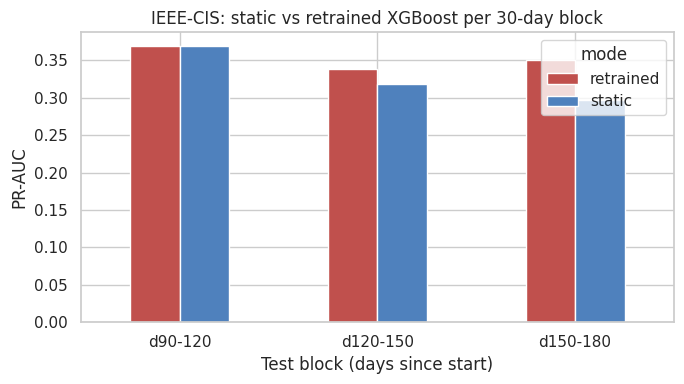

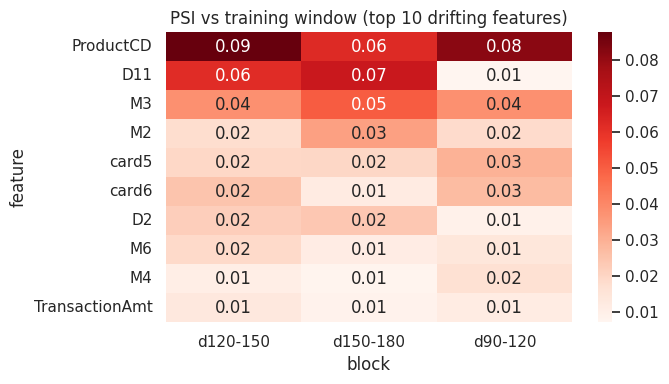

,retrained,static,mean_psi,share_psi_gt_0.25
block,,,,
d90-120,0.369,0.369,0.010,0.0
d120-150,0.338,0.318,0.011,0.0
d150-180,0.351,0.297,0.011,0.0


In [8]:
piv = B_sum.pivot(index="block", columns="mode", values="pr_auc").reindex(
    B_sum.drop_duplicates("block").sort_values("block_start")["block"])
ax = piv.plot(kind="bar", figsize=(7, 4), color=["#c0504d", "#4f81bd"][:piv.shape[1]], rot=0)
ax.set_ylabel("PR-AUC"); ax.set_xlabel("Test block (days since start)")
ax.set_title("IEEE-CIS: static vs retrained XGBoost per 30-day block"); plt.tight_layout()
plt.savefig(FIGDIR / "rq6_drift_prauc.png", dpi=150); plt.show()

top = P.groupby("feature")["psi"].max().sort_values(ascending=False).head(10).index
heat = P[P["feature"].isin(top)].pivot(index="feature", columns="block", values="psi").loc[top]
plt.figure(figsize=(7, 4)); sns.heatmap(heat, annot=True, fmt=".2f", cmap="Reds")
plt.title("PSI vs training window (top 10 drifting features)"); plt.tight_layout()
plt.savefig(FIGDIR / "rq6_psi_heatmap.png", dpi=150); plt.show()

mean_psi = P.groupby("block")["psi"].mean().rename("mean_psi")
share_hi = P.assign(hi=P["psi"] > 0.25).groupby("block")["hi"].mean().rename("share_psi_gt_0.25")
summary = piv.join(mean_psi).join(share_hi).round(3); summary.to_csv(OUTDIR / "rq6_drift_overview.csv"); summary

## Numbers to paste back

In [9]:
print("PART A"); print(A_sum.to_string())
print("\nPART B"); print(B_sum.to_string(index=False))
print("\nDRIFT OVERVIEW"); print(summary.to_string())
print("\nTop PSI features:"); print(P.groupby("feature")["psi"].max().sort_values(ascending=False).head(10).round(3).to_string())

PART A
         precision        recall            f1        pr_auc        roc_auc        train_s        predict_s       
              mean    std   mean    std   mean    std   mean    std    mean    std    mean    std      mean    std
model                                                                                                             
CatBoost     0.129  0.001  0.688  0.007  0.217  0.002  0.299  0.002   0.850  0.002  30.721  0.839     0.052  0.006
LightGBM     0.164  0.014  0.575  0.013  0.255  0.015  0.291  0.008   0.843  0.001   9.591  0.980     1.389  0.309
XGBoost      0.203  0.000  0.512  0.000  0.291  0.000  0.287  0.000   0.843  0.000  11.241  0.347     0.478  0.065

PART B
   block  block_start      mode  pr_auc  roc_auc  recall  precision    f1  prevalence
 d90-120           90 retrained   0.369    0.862   0.651      0.186 0.289       0.040
 d90-120           90    static   0.369    0.862   0.651      0.186 0.289       0.040
d120-150          120 retrained   0.3